In [60]:
# Imports
from ucimlrepo import fetch_ucirepo 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
# ROC Curve e AUC (multiclasse - One-vs-Rest)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [61]:
# Configurar device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")

Usando device: cpu


Shape do target: (235795,)
Classes: [0 1]

Distribuição das Classes:
target
1    134850
0    100945
Name: count, dtype: int64


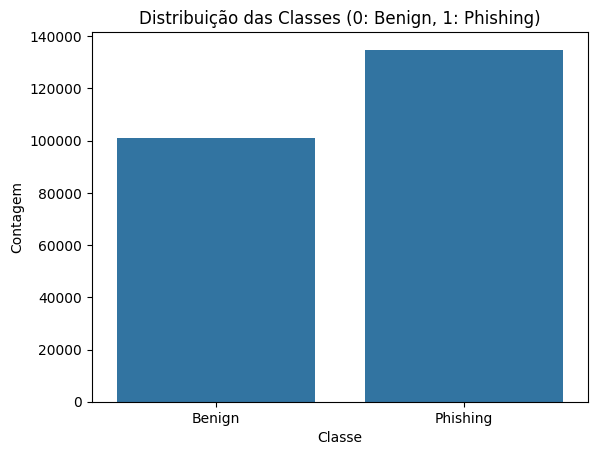

In [62]:

# fetch dataset 
phishing_dataset = fetch_ucirepo(id=967) 

# data (as pandas dataframes) 
# data (as pandas dataframes) 
X = phishing_dataset.data.features 
y = phishing_dataset.data.targets 

# O target está como 'string', vamos converter para numérico (0 para 'benign', 1 para 'phishing')
y = y.iloc[:, 0].astype('category').cat.codes

# Converter APENAS y para numpy array por enquanto
y = y.values
print("Shape do target:", y.shape)
print("Classes:", np.unique(y))

# Criar um DataFrame para visualização
df = pd.DataFrame(X, columns=phishing_dataset.data.feature_names)
df['target'] = y

# Verificar o balanceamento
print("\nDistribuição das Classes:")
print(df['target'].value_counts())

sns.countplot(x='target', data=df)
plt.title('Distribuição das Classes (0: Benign, 1: Phishing)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(ticks=[0, 1], labels=['Benign', 'Phishing'])
plt.show()

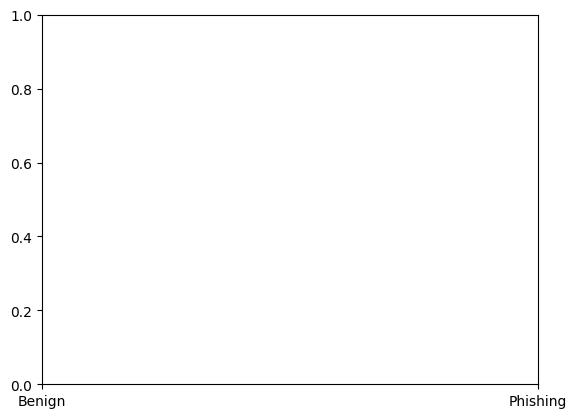

Colunas numéricas a serem escaladas: 50


In [63]:
plt.xticks(ticks=[0, 1], labels=['Benign', 'Phishing'])
plt.show()

# --- CÉLULA DE PRÉ-PROCESSAMENTO (AGORA FUNCIONA) ---
# Identificar colunas numéricas para escalar
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
print(f"Colunas numéricas a serem escaladas: {len(numeric_features)}")

scaler = StandardScaler()

# Criar uma cópia para evitar SettingWithCopyWarning
X_scaled_df = X.copy()

# Aplicar o scaler apenas nas colunas numéricas
X_scaled_df[numeric_features] = scaler.fit_transform(X[numeric_features])

# Agora, converta o DataFrame processado para numpy array
X_scaled = X_scaled_df.values

# Divisão (train / validation / test)
# ...existing code...

In [64]:
# Divisão (train / validation / test)
# Dividir em treino (60%), validação (20%) e teste (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# veificar se stá balanceado
print(f"Treino: {np.bincount(y_train)}")
print(f"Validação: {np.bincount(y_val)}")
print(f"Teste: {np.bincount(y_test)}")

# Converter para tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: [60567 80910]
Validação: [20189 26970]
Teste: [20189 26970]


TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [ ]:
# Arquitetura da MLP
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

# Parâmetros do modelo
input_size = X.shape[1]  # Número de features do dataset de phishing
hidden_size = 64         # Aumentado para um dataset mais complexo
num_classes = 2          # 2 classes: 'benign' e 'phishing'
learning_rate = 0.001
num_epochs = 200

# Instanciar modelo
model = MLP(input_size, hidden_size, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Modelo criado com arquitetura: {input_size} -> {hidden_size} -> {hidden_size} -> {num_classes}")

Modelo criado com arquitetura: 4 -> 4 -> 4 -> 3


In [ ]:
# Treinamento
# Listas para armazenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Função para calcular acurácia
def calculate_accuracy(outputs, targets):
    _, predicted = torch.max(outputs.data, 1)
    total = targets.size(0)
    correct = (predicted == targets).sum().item()
    return 100 * correct / total

print("Iniciando treinamento...")
for epoch in range(num_epochs):
    # Modo treino
    model.train()
    train_outputs = model(X_train_tensor)
    train_loss = criterion(train_outputs, y_train_tensor)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    # Avaliação no conjunto de validação
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Calcular acurácias
        train_acc = calculate_accuracy(train_outputs, y_train_tensor)
        val_acc = calculate_accuracy(val_outputs, y_val_tensor)
        
        # Armazenar métricas
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
    
    # Print a cada 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss.item():.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.2f}%')

print("Treinamento concluído!")

Iniciando treinamento...
Epoch [20/200], Train Loss: 1.1140, Train Acc: 33.33%, Val Loss: 1.1129, Val Acc: 33.33%
Epoch [40/200], Train Loss: 1.1059, Train Acc: 33.33%, Val Loss: 1.1046, Val Acc: 33.33%
Epoch [60/200], Train Loss: 1.0976, Train Acc: 33.33%, Val Loss: 1.0961, Val Acc: 33.33%
Epoch [80/200], Train Loss: 1.0868, Train Acc: 33.33%, Val Loss: 1.0855, Val Acc: 33.33%
Epoch [100/200], Train Loss: 1.0720, Train Acc: 33.33%, Val Loss: 1.0710, Val Acc: 33.33%
Epoch [120/200], Train Loss: 1.0449, Train Acc: 41.11%, Val Loss: 1.0456, Val Acc: 43.33%
Epoch [140/200], Train Loss: 0.9951, Train Acc: 82.22%, Val Loss: 0.9967, Val Acc: 86.67%
Epoch [160/200], Train Loss: 0.9270, Train Acc: 90.00%, Val Loss: 0.9278, Val Acc: 90.00%
Epoch [180/200], Train Loss: 0.8445, Train Acc: 88.89%, Val Loss: 0.8447, Val Acc: 90.00%
Epoch [200/200], Train Loss: 0.7545, Train Acc: 90.00%, Val Loss: 0.7546, Val Acc: 86.67%
Treinamento concluído!


In [ ]:
# Avaliação no conjunto de teste
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    test_acc = calculate_accuracy(test_outputs, y_test_tensor)
    
    # Predições detalhadas
    _, predicted = torch.max(test_outputs.data, 1)
    
print(f'\nResultados Finais:')
print(f'Acurácia no conjunto de teste: {test_acc:.2f}%')
print(f'Loss no conjunto de teste: {test_loss.item():.4f}')


Resultados Finais:
Acurácia no conjunto de teste: 76.67%
Loss no conjunto de teste: 0.7934


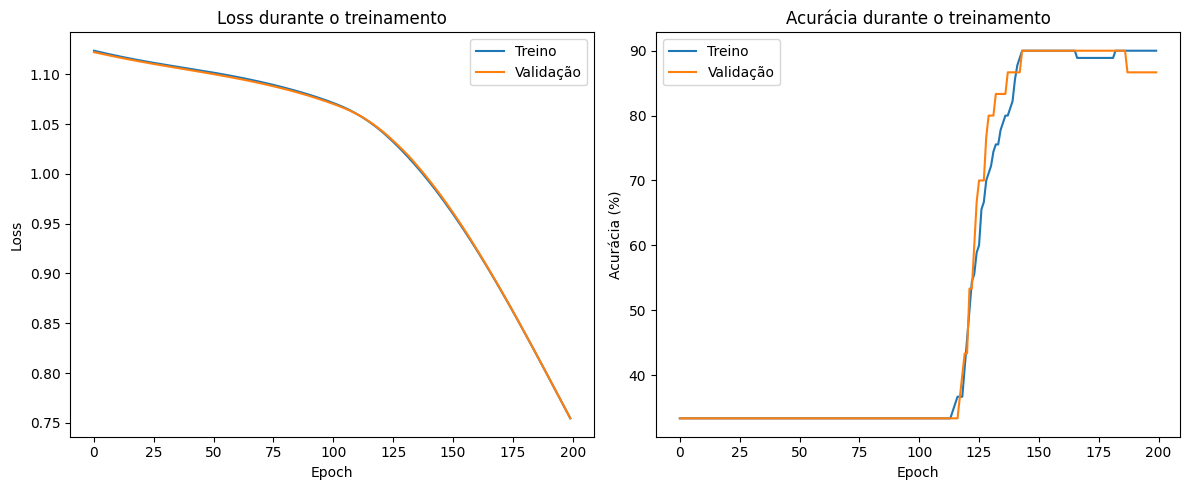

In [ ]:
# Diagnóstico - Visualizar curvas de aprendizado
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.title('Loss durante o treinamento')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Treino')
plt.plot(val_accuracies, label='Validação')
plt.title('Acurácia durante o treinamento')
plt.xlabel('Epoch')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

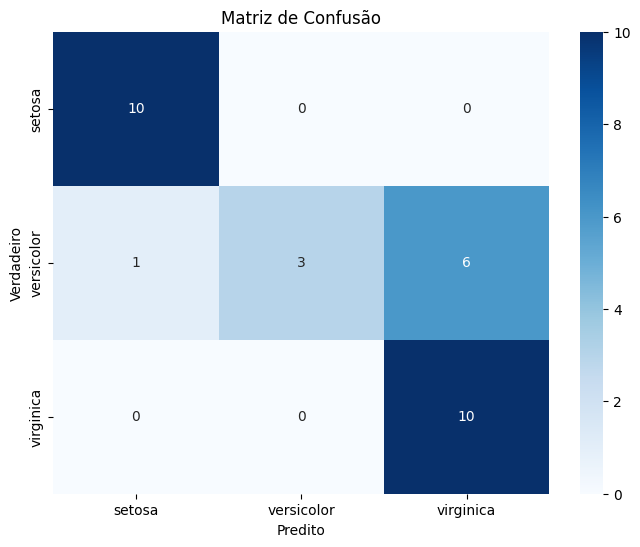


Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       1.00      0.30      0.46        10
   virginica       0.62      1.00      0.77        10

    accuracy                           0.77        30
   macro avg       0.84      0.77      0.73        30
weighted avg       0.84      0.77      0.73        30



In [ ]:
# Diagnóstico - Matriz de confusão
y_pred = predicted.cpu().numpy()
y_true = y_test

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Phishing'], 
            yticklabels=['Benign', 'Phishing'])
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Phishing']))

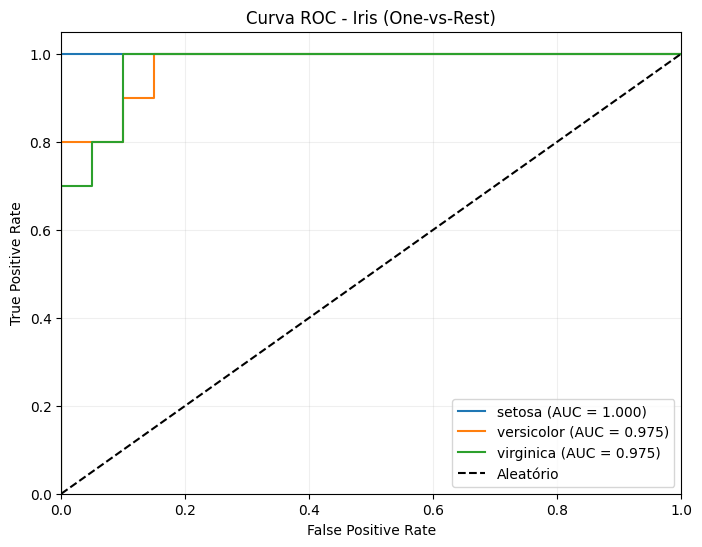

AUC Macro (OvR): 0.9833
AUC Weighted (OvR): 0.9833


In [ ]:
# ROC Curve e AUC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

model.eval()
with torch.no_grad():
    logits_test = model(X_test_tensor)
    # Para classificação binária, a saída para a classe positiva é o segundo neurônio
    y_score = torch.softmax(logits_test, dim=1)[:, 1].cpu().numpy()

y_true = y_test

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Phishing Dataset')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [ ]:
# Salvamento do modelo
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler': scaler,
    'model_params': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_classes': num_classes
    }
}, 'iris_mlp_model.pth')

print("Modelo salvo como 'iris_mlp_model.pth'")

Modelo salvo como 'iris_mlp_model.pth'
